<a href="https://colab.research.google.com/github/almabaconawa/Data-Analytics-projects/blob/main/Crime_Rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIND123 LAB 10 Solutions


### Q1. Load the `Boston` dataset from the `MASS` package via `statsmodels`. Check data types, and convert variables that should be categorical. Check for the missing values in the dataset.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load Boston dataset
boston = sm.datasets.get_rdataset("Boston", "MASS").data

print("Original data types:")
print(boston.dtypes)

# Convert categorical variables
boston['chas'] = boston['chas'].astype('category')
boston['rad'] = boston['rad'].astype('category')

print("\nUpdated data types after conversion:")
print(boston.dtypes)

print(boston.isnull().sum())

Original data types:
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
black      float64
lstat      float64
medv       float64
dtype: object

Updated data types after conversion:
crim        float64
zn          float64
indus       float64
chas       category
nox         float64
rm          float64
age         float64
dis         float64
rad        category
tax           int64
ptratio     float64
black       float64
lstat       float64
medv        float64
dtype: object
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64


### Q2. Display the first 6 rows and provide summary statistics.

In [ ]:

print(boston.head(6))
print(boston.describe(include="all"))


      crim    zn  indus chas    nox     rm   age     dis rad  tax  ptratio  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222     18.7   
5  0.02985   0.0   2.18    0  0.458  6.430  58.7  6.0622   3  222     18.7   

    black  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
5  394.12   5.21  28.7  
              crim          zn       indus   chas         nox          rm  \
count   506.000000  506.000000  506.000000  506.0  506.000000  506.000000   
unique         NaN         NaN         NaN    2.0         NaN         NaN   
top            NaN         NaN         NaN    0

### Q3. Compute the mean and median of `crim` (crime rate) and `medv` (median house value).

In [ ]:

print("Mean crim:", boston['crim'].mean())
print("Median crim:", boston['crim'].median())
print("Mean medv:", boston['medv'].mean())
print("Median medv:", boston['medv'].median())


Mean crim: 3.613523557312254
Median crim: 0.25651
Mean medv: 22.532806324110677
Median medv: 21.2


### Q4. Create a histogram of `medv`. What can you infer about its distribution?

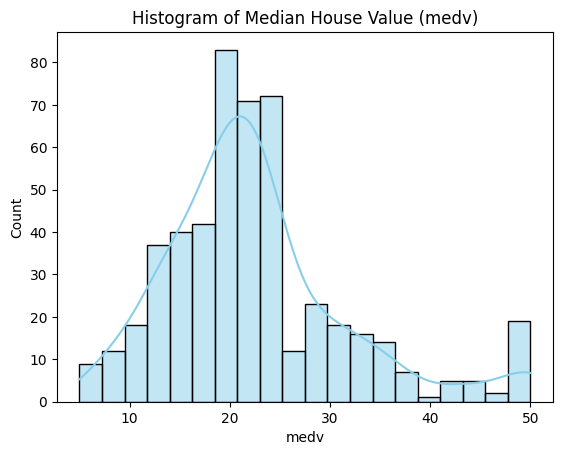

In [ ]:

sns.histplot(boston['medv'], bins=20, kde=True, color="skyblue")
plt.title("Histogram of Median House Value (medv)")
plt.xlabel("medv")
plt.ylabel("Count")
plt.show()


### Q5. Create a scatter plot of `lstat` vs `medv`. Add axis labels and a title.

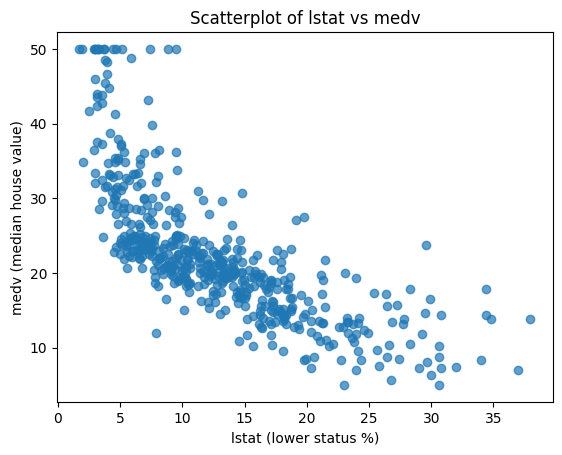

In [ ]:

plt.scatter(boston['lstat'], boston['medv'], alpha=0.7)
plt.title("Scatterplot of lstat vs medv")
plt.xlabel("lstat (lower status %)")
plt.ylabel("medv (median house value)")
plt.show()


### Q6. Create a boxplot showing distribution of `medv` by `chas`.

/tmp/ipython-input-4111480702.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="chas", y="medv", data=boston, palette="Set2")


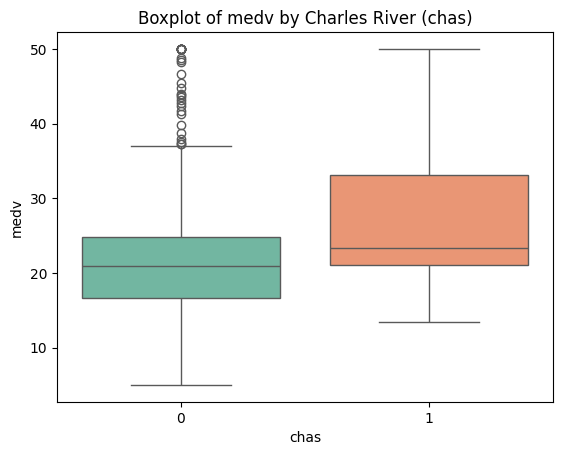

In [ ]:

sns.boxplot(x="chas", y="medv", data=boston, palette="Set2")
plt.title("Boxplot of medv by Charles River (chas)")
plt.show()


### Q7. Compute Pearson correlation among continuous numeric variables (exclude `chas` and `rad`).

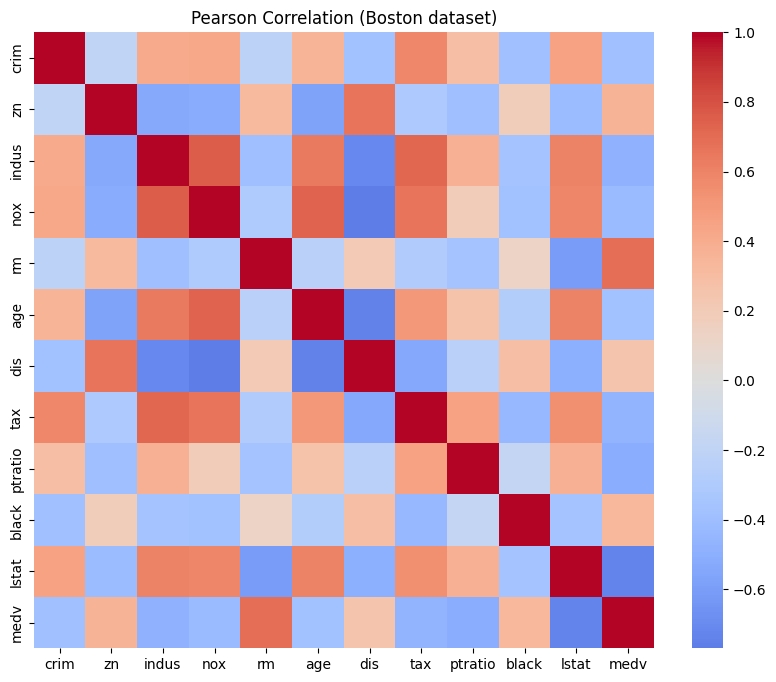

In [ ]:

numeric_boston = boston.drop(columns=['chas','rad'])
corr = numeric_boston.corr(method="pearson")

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Pearson Correlation (Boston dataset)")
plt.show()


### Q8. Fit a simple linear regression model with `medv ~ lstat`. Display the summary.

In [ ]:

model1 = smf.ols("medv ~ lstat", data=boston).fit()
print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Wed, 01 Oct 2025   Prob (F-statistic):           5.08e-88
Time:                        19:20:24   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.5538      0.563     61.415      0.0

### Q9. Plot the regression line for `medv` on `lstat`.

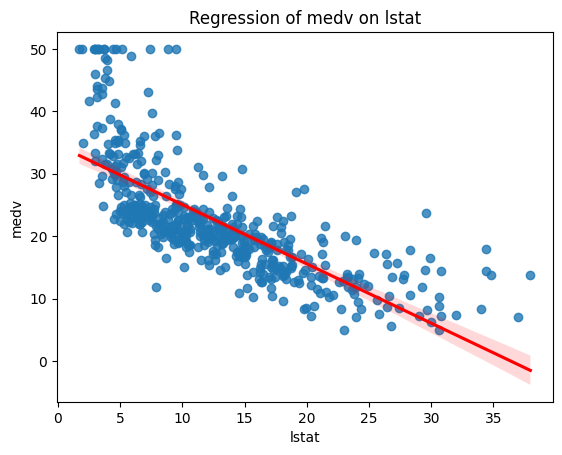

In [ ]:

sns.regplot(x="lstat", y="medv", data=boston, line_kws={"color":"red"})
plt.title("Regression of medv on lstat")
plt.show()


### Q10. Fit a multiple regression with `medv ~ lstat + rm + age`. Display the summary.

In [ ]:

model2 = smf.ols("medv ~ lstat + rm + age", data=boston).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     296.2
Date:                Wed, 01 Oct 2025   Prob (F-statistic):          1.20e-110
Time:                        19:20:31   Log-Likelihood:                -1582.4
No. Observations:                 506   AIC:                             3173.
Df Residuals:                     502   BIC:                             3190.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1753      3.182     -0.369      0.7

### Q11. Create a residual plot for the multiple regression model.

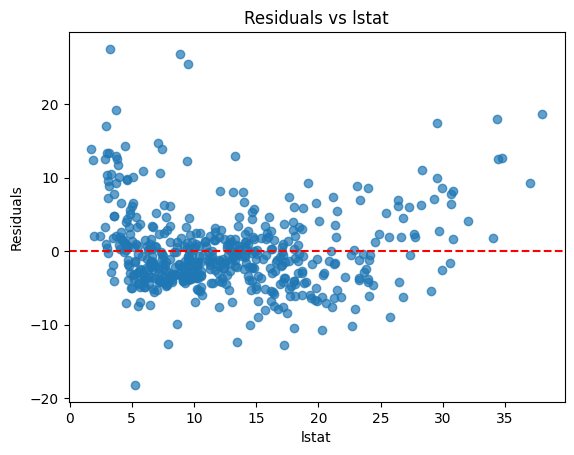

In [ ]:

residuals = model2.resid
plt.scatter(boston['lstat'], residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs lstat")
plt.xlabel("lstat")
plt.ylabel("Residuals")
plt.show()


### Q12. Use the fitted multiple linear regression model to predict the median value of a home (medv) for a location where the lower status population (lstat) is 10, the average number of rooms (rm) is 6, and the house age (age) is 60.

In [ ]:
# New data point
new_data = pd.DataFrame({
    "lstat": [10],
    "rm": [6],
    "age": [60]
})

# Prediction
predicted_value = model2.predict(new_data)
print("Predicted median value of home:", predicted_value[0])


Predicted median value of home: 22.79983851129617


This is the end of the lab.

Ceni Babaoglu, PhD

The G. Raymond Chang School of Continuing Education Toronto Metropolitan University

